In [230]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [231]:
# Load cleaned data
PROCESSED_PATH = os.path.join('..', 'data', 'processed')

df = pd.read_pickle(os.path.join(PROCESSED_PATH, 'df_cleaned.pkl'))

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Data loaded: 2,049,280 rows × 20 columns


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,year,month,day,hour,minute,day_of_week,day_of_year,week_of_year,quarter,is_weekend,time_of_day,season
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006,12,16,17,24,5,350,50,4,1,Afternoon,Winter
1,2006-12-16 17:25:00,4.850,0.436,233.63,20.6,0.0,1.0,16.0,2006,12,16,17,25,5,350,50,4,1,Afternoon,Winter
2,2006-12-16 17:26:00,4.850,0.478,233.29,20.6,0.0,2.0,17.0,2006,12,16,17,26,5,350,50,4,1,Afternoon,Winter
3,2006-12-16 17:27:00,4.850,0.478,233.74,20.6,0.0,1.0,17.0,2006,12,16,17,27,5,350,50,4,1,Afternoon,Winter
4,2006-12-16 17:28:00,3.666,0.478,235.68,15.8,0.0,1.0,17.0,2006,12,16,17,28,5,350,50,4,1,Afternoon,Winter


In [232]:
df_filtered = df[['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3',
                   'is_weekend','time_of_day','season']].copy()

In [233]:

numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
]

corr = df_filtered[numeric_cols].corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

#Identify and then remove highly correlated columns for better analysis
to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly correlated columns:", to_drop)

Highly correlated columns: ['Global_intensity']


In [234]:
#Discretization
df_filtered['Global_active_power_bin'] = pd.qcut(df_filtered['Global_active_power'],q=3,labels=['Low','Medium','High'])
df_filtered['Global_reactive_power_bin'] = pd.qcut(df_filtered['Global_reactive_power'],q=3,labels=['Low','Medium','High'])
df_filtered['Voltage_bin'] = pd.qcut(df_filtered['Voltage'],q=3,labels=['Low','Normal','High'])

df_filtered['Sub_metering_1_bin'] = pd.cut(df_filtered['Sub_metering_1'],bins=[-1,2,5,50],labels=['Low','Medium','High'])
df_filtered['Sub_metering_2_bin'] = pd.cut(df_filtered['Sub_metering_2'],bins=[-1,2,5,50],labels=['Low','Medium','High'])
df_filtered['Sub_metering_3_bin'] = pd.cut(df_filtered['Sub_metering_3'],bins=[-1,2,5,50],labels=['Low','Medium','High'])

#Drop numeric columns
to_drop += ['Global_active_power','Global_reactive_power','Voltage','Sub_metering_1','Sub_metering_2','Sub_metering_3']

df_filtered.drop(columns=to_drop, inplace=True)

#Convert int to string
df_filtered['is_weekend'] = df_filtered['is_weekend'].astype(str)
df_filtered.head()

,is_weekend,time_of_day,season,Global_active_power_bin,Global_reactive_power_bin,Voltage_bin,Sub_metering_1_bin,Sub_metering_2_bin,Sub_metering_3_bin
0,1,Afternoon,Winter,High,High,Low,Low,Low,High
1,1,Afternoon,Winter,High,High,Low,Low,Low,High
2,1,Afternoon,Winter,High,High,Low,Low,Low,High
3,1,Afternoon,Winter,High,High,Low,Low,Low,High
4,1,Afternoon,Winter,High,High,Low,Low,Low,High


In [235]:
#Split training and testing data
train_size = int(len(df_filtered) * 0.7) # 70/30
train_data = df_filtered.iloc[:train_size]
test_data  = df_filtered.iloc[train_size:]

In [236]:
#Estimating using TreeSearch model
from pgmpy.estimators import TreeSearch
ts = TreeSearch(train_data)
ts_model = ts.estimate()

Building tree:   0%|          | 0/36.0 [00:00<?, ?it/s]

In [237]:
#Estimating using HillClimbSearch model
from pgmpy.estimators import (HillClimbSearch,BIC)

hc = HillClimbSearch(train_data)
hc_model = hc.estimate(scoring_method=BIC(train_data))

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [243]:
print(f"TreeSearch Model Edges: {len(ts_model.edges())}, Nodes: {len(ts_model.nodes())}")
print(f"HillClimbSearch Model Edges: {len(hc_model.edges())}, Nodes: {len(hc_model.nodes())}")


TreeSearch Model Edges: 8, Nodes: 9
HillClimbSearch Model Edges: 28, Nodes: 9


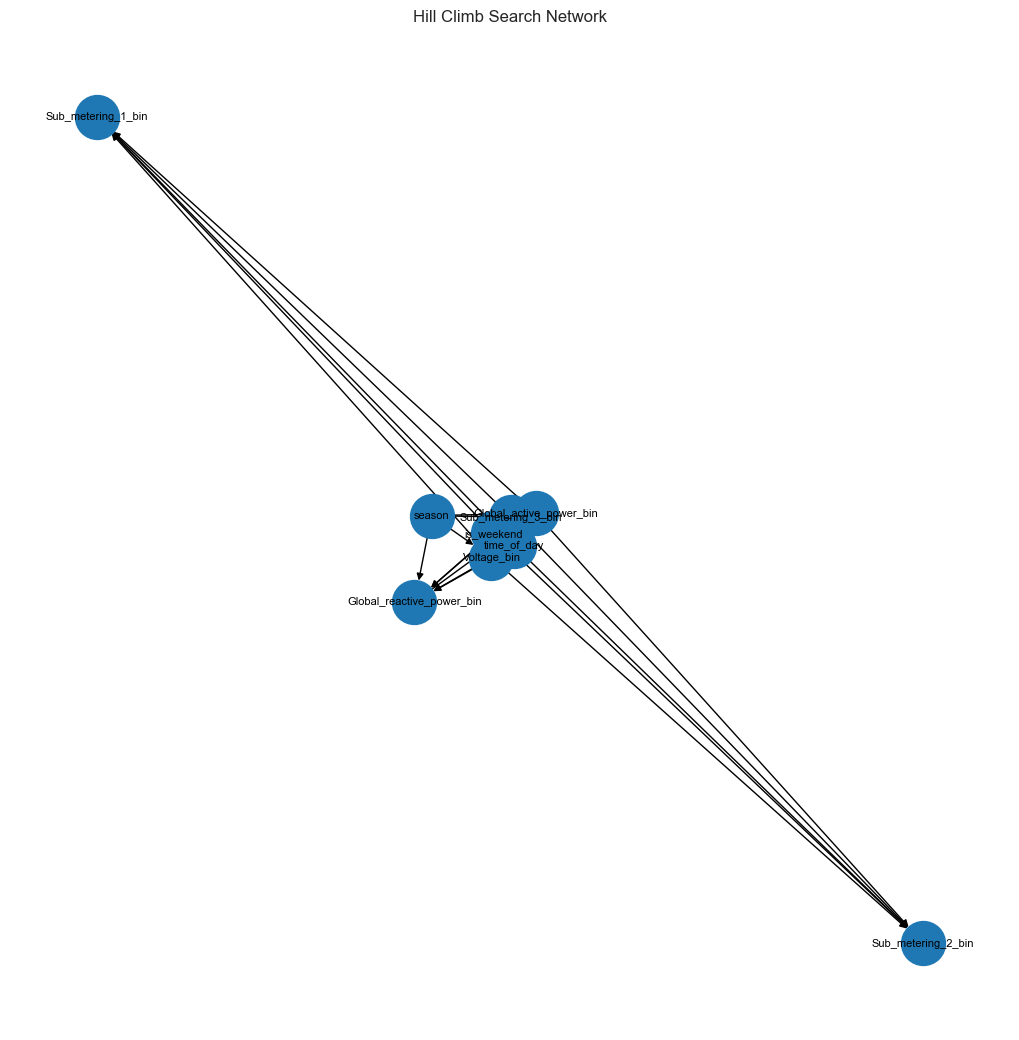

In [250]:
import networkx as nx
plt.figure(figsize=(10,10))
G = nx.DiGraph(hc_model.edges())
pos = nx.spring_layout(G, seed=42)
nx.draw(G,pos,with_labels=True,node_size=1000,font_size=8)
plt.title("Hill Climb Search Network")
plt.show()

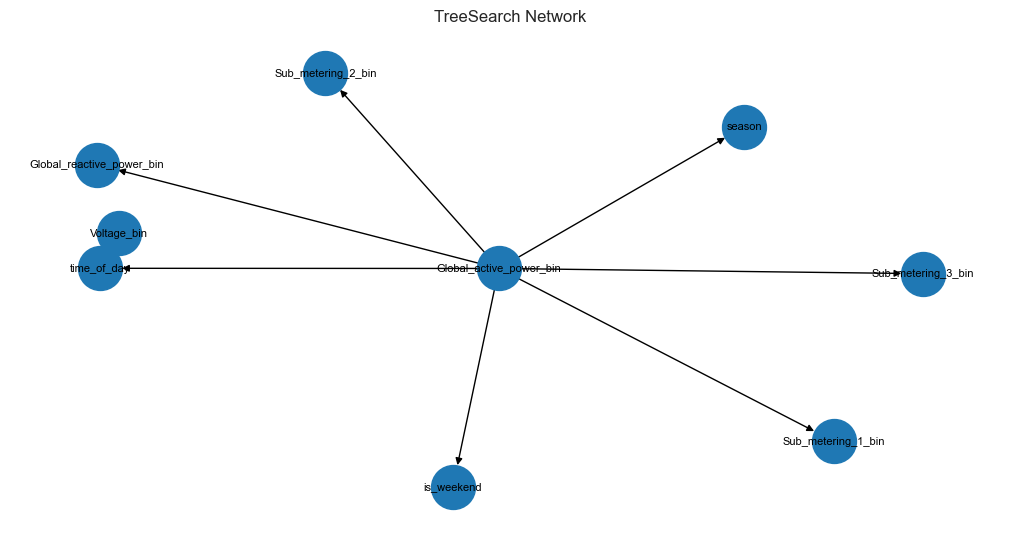

In [251]:
plt.figure(figsize=(10,5))
G = nx.DiGraph(ts_model.edges())
pos = nx.spring_layout(G, seed=42)
nx.draw(G,pos,with_labels=True,node_size=1000,font_size=8)
plt.title("TreeSearch Network")
plt.show()

In [252]:
#Creating cpds and checking model validity
from pgmpy.estimators import MaximumLikelihoodEstimator
ts_bn = DiscreteBayesianNetwork(ts_model.edges())
mle = MaximumLikelihoodEstimator(ts_bn, train_data)

for node in ts_bn.nodes():
    cpd = mle.estimate_cpd(node)
    ts_bn.add_cpds(cpd)

ts_bn.check_model()

True

In [253]:
from pgmpy.estimators import MaximumLikelihoodEstimator
hc_bn = DiscreteBayesianNetwork(hc_model.edges())
mle = MaximumLikelihoodEstimator(hc_bn, train_data)

for node in hc_bn.nodes():
    cpd = mle.estimate_cpd(node)
    hc_bn.add_cpds(cpd)

hc_bn.check_model()

True

In [254]:
#Inference from HillClimbSearch model based estimation
from pgmpy.inference import VariableElimination

def ask(q:str,evidence:dict, inference,vars=['Global_active_power_bin'], ):
    p = inference.query(variables=vars,evidence=evidence,show_progress=False)
    prob = p.values[0] * 100
    print(f"{q}, there is {prob:f}% chance of {"".join(vars)} usage")

infer = VariableElimination(hc_bn)
print("Inference based on HillClimbSearch model - Global_active_power")
ask("Given it is an evening",{'time_of_day':'Evening'},infer) 
ask("Given it is a weekend",{'is_weekend':'1'},infer)
ask("Given it is an evening and a weekend",{'time_of_day':'Evening','is_weekend':'1'},infer) 
ask("Given it is an evening and is NOT a weekend",{'time_of_day':'Evening','is_weekend':'0'},infer)
ask("Given it is a night and weekend",{'time_of_day':'Night','is_weekend':'1'},infer)
ask("Given it is Winter",{'season':'Winter'},infer)
ask("Given it is Winter and weekend",{'season':'Winter','is_weekend':'1'},infer)

print("---------------------------------------------------------------------")
print("Inference based on HillClimbSearch model - Global_reactive_power")
ask("Given it is a weekend",{'is_weekend':'1'},infer,['Global_reactive_power_bin'])
ask("Given it is Summer",{'season':'Summer'},infer,['Global_reactive_power_bin'])
ask("Given it is Summer and weekend",{'season':'Summer','is_weekend':'1'},infer,['Global_reactive_power_bin'])

Inference based on HillClimbSearch model - Global_active_power
Given it is an evening, there is 53.832496% chance of Global_active_power_bin usage
Given it is a weekend, there is 37.380129% chance of Global_active_power_bin usage
Given it is an evening and a weekend, there is 60.780638% chance of Global_active_power_bin usage
Given it is an evening and is NOT a weekend, there is 51.077802% chance of Global_active_power_bin usage
Given it is a night and weekend, there is 19.910213% chance of Global_active_power_bin usage
Given it is Winter, there is 46.186398% chance of Global_active_power_bin usage
Given it is Winter and weekend, there is 54.059376% chance of Global_active_power_bin usage
---------------------------------------------------------------------
Inference based on HillClimbSearch model - Global_reactive_power
Given it is a weekend, there is 37.235170% chance of Global_reactive_power_bin usage
Given it is Summer, there is 41.010285% chance of Global_reactive_power_bin usage


In [255]:
#Inference from TreeSearch model based estimation

print("Inference based on TreeSearch model - Global_active_power")
infer = VariableElimination(ts_bn)
ask("Given it is an evening",{'time_of_day':'Evening'},infer) 
ask("Given it is a weekend",{'is_weekend':'1'},infer)
ask("Given it is an evening and a weekend",{'time_of_day':'Evening','is_weekend':'1'},infer) 
ask("Given it is an evening and is NOT a weekend",{'time_of_day':'Evening','is_weekend':'0'},infer)
ask("Given it is a night and weekend",{'time_of_day':'Night','is_weekend':'1'},infer)
ask("Given it is Winter",{'season':'Winter'},infer)
ask("Given it is Winter and weekend",{'season':'Winter','is_weekend':'1'},infer)

print("---------------------------------------------------------------------")
print("Inference based on TreeSearch model - Global_reactive_power")
ask("Given it is Summer",{'season':'Summer'},infer,['Global_reactive_power_bin'])
ask("Given it is Summer and weekend",{'season':'Summer','is_weekend':'1'},infer,['Global_reactive_power_bin'])

Inference based on TreeSearch model - Global_active_power
Given it is an evening, there is 53.845029% chance of Global_active_power_bin usage
Given it is a weekend, there is 37.398775% chance of Global_active_power_bin usage
Given it is an evening and a weekend, there is 59.113038% chance of Global_active_power_bin usage
Given it is an evening and is NOT a weekend, there is 51.584118% chance of Global_active_power_bin usage
Given it is a night and weekend, there is 17.871710% chance of Global_active_power_bin usage
Given it is Winter, there is 46.185708% chance of Global_active_power_bin usage
Given it is Winter and weekend, there is 51.720869% chance of Global_active_power_bin usage
---------------------------------------------------------------------
Inference based on TreeSearch model - Global_reactive_power
Given it is Summer, there is 27.036403% chance of Global_reactive_power_bin usage
Given it is Summer and weekend, there is 28.159950% chance of Global_reactive_power_bin usage


In [256]:
#BIC and K2 scoring computing and determing best model
from pgmpy.estimators import BIC,K2
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

bic=BIC(train_data)
k2=K2(train_data)
hc_bic_score = bic.score(hc_bn) 
hc_k2_score = k2.score(hc_bn)
ts_bic_score = bic.score(ts_bn)
ts_k2_score = k2.score(ts_bn)
print(f"HillClimbSearch bic_score: {hc_bic_score}, K2 score: {hc_k2_score}")
print(f"TreeSearch bic_score: {ts_bic_score}, K2 score: {ts_k2_score}")

if hc_bic_score > ts_bic_score:
    print("HillClimbSearch Model performs better than Treesearch with BIC Score")
else:
    print("Treesearch Model performs better than HillClimbSearch with BIC Score")

if hc_k2_score > ts_k2_score:
    print("HillClimbSearch Model performs better than Treesearch with K2 Score")
else:
    print("Treesearch Model performs better than HillClimbSearch with K2 Score")


HillClimbSearch bic_score: -9752909.791497367, K2 score: -9741352.293505067
TreeSearch bic_score: -10106518.127775973, K2 score: -10106510.236211818
HillClimbSearch Model performs better than Treesearch with BIC Score
HillClimbSearch Model performs better than Treesearch with K2 Score


In [257]:
def compute_accuracy_auc(model,model_name,dataset,var_name,var_value):
    infer = VariableElimination(model)
    y_true = []
    y_prob = []

    sample_data = test_data.sample(n=min(5000, len(test_data)), random_state=45)
    
    for _, row in sample_data.iterrows():
        evidence = row.drop(var_name).to_dict()
        q = infer.query(variables=[var_name],evidence=evidence,show_progress=False)
        prob_hd = q.values[0]
        y_true.append((int)(row[var_name]==var_value))
        y_prob.append(prob_hd)

    y_pred = [1 if p > 0.5 else 0 for p in y_prob]

    accuracy = accuracy_score(y_true,y_pred)
    print(f"{model_name} Accuracy: {accuracy*100}%")

    auc = roc_auc_score(y_true,y_prob)
    print(f"{model_name} AUC: {auc*100}%")

In [258]:
compute_accuracy_auc(hc_bn,"HillClimbSearch",test_data,"Global_active_power_bin","High")

HillClimbSearch Accuracy: 89.0%
HillClimbSearch AUC: 95.15975090927627%


In [259]:
compute_accuracy_auc(ts_bn,"TreeSearch",test_data,"Global_active_power_bin","High")

TreeSearch Accuracy: 88.58%
TreeSearch AUC: 93.84034509393014%


## Summary
***Bayesian Network modeling is required because:***
1. Noticed that there are related variables
2. Temporal and behavioural dependencies exist
3. Explanability is important

### Methods studied
1. **Treesearch**
2. **HillClimbSearch**

### Steps followed
1. **Discretization** - Converting all numberic variables to discrete form/categorized.
2. **Structured learning** - Expert Knowledge, BIC and K2 scores
3. **Parameter Learning and Inference** - Infer how given specific parameters (Global_active_power and Global_reactive_power)
   influence other parameters
4. **Evaluation** - Using deduced BIC, K2 scores, and accuracy - Inferred ***HillClimbSearch*** performs better.